In [1]:
# === Setup ===
import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1) Daten laden

In [2]:
# Daten-Datei (CSV) – hier entweder im Notebook-Ordner oder im /mnt/data Ordner.
CSV_PATH = "free_throw_dataset.csv"
if not os.path.exists(CSV_PATH):
    alt = os.path.join("/mnt/data", CSV_PATH)
    if os.path.exists(alt):
        CSV_PATH = alt

df = pd.read_csv(CSV_PATH)
print("CSV_PATH:", CSV_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

CSV_PATH: free_throw_dataset.csv
(7500, 12)
['wurf_id', 't', 'x_clean', 'y_clean', 'x_noisy', 'y_noisy', 'x', 'y', 'T', 'label', 'theta', 'v0']


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0
0,0,0.000000,0.000000,2.662500,0.157921,2.578578,0.157921,2.578578,0.696893,0,0.70767,6.107672
1,0,0.014222,0.066007,2.717976,0.142750,2.687055,0.142750,2.687055,0.696893,0,0.70767,6.107672
2,0,0.028445,0.132014,2.771469,0.085067,2.804595,0.085067,2.804595,0.696893,0,0.70767,6.107672
3,0,0.042667,0.198021,2.822978,0.252277,2.920532,0.252277,2.920532,0.696893,0,0.70767,6.107672
4,0,0.056889,0.264028,2.872503,0.217686,2.824585,0.217686,2.824585,0.696893,0,0.70767,6.107672


In [3]:
# Pro Wurf aggregieren
per_throw = df.groupby("wurf_id").agg({
    "label":"first",
    "theta":"first",
    "v0":"first",
    "T":"first"
}).reset_index()

print("Anzahl Würfe:", per_throw.shape[0])
print(per_throw["label"].value_counts())
per_throw.head()

Anzahl Würfe: 150
label
0    50
1    50
2    50
Name: count, dtype: int64


,wurf_id,label,theta,v0,T
0,0,0,0.707670,6.107672,0.696893
1,1,1,0.889089,6.662367,0.974337
2,2,2,0.759879,6.803414,0.864825
3,3,0,0.762547,6.383944,0.801193
4,4,1,0.793452,6.633317,0.874307


## 2) Train/Val/Test Split (nach `wurf_id`, stratifiziert nach Label)

In [4]:
# labels_by_id = df.groupby("wurf_id")["label"].first().to_dict()

# all_ids = np.array(sorted(labels_by_id.keys()))
# all_y = np.array([labels_by_id[i] for i in all_ids])

# train_ids, temp_ids, y_train, y_temp = train_test_split(
#     all_ids, all_y, test_size=0.3, stratify=all_y, random_state=42  # z.B. 70/30
# )

# val_ids, test_ids, y_val, y_test = train_test_split(
#     temp_ids,
#     y_temp,
#     test_size=0.5,  # 0.5 von 30% = 15%/15%
#     stratify=y_temp,
#     random_state=42,
# )

# train_ids = train_ids.tolist()
# val_ids = val_ids.tolist()
# test_ids = test_ids.tolist()

# print("Train IDs:", len(train_ids))
# print("Val IDs:", len(val_ids))
# print("Test IDs:", len(test_ids))
train_ids, test_ids = train_test_split(
    per_throw["wurf_id"].values,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw["label"].values,
)
train_ids, val_ids = train_test_split(
    train_ids,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw.set_index("wurf_id").loc[train_ids, "label"].values,
)

print("Train/Val/Test:", len(train_ids), len(val_ids), len(test_ids))
print("Alle Test ids:", test_ids)

Train/Val/Test: 107 20 23
Alle Test ids: [131 119  84 124  24  22   9  11  89  57 148  31  69  85  71 141   1  41
 117 106  42 143  70]


## 3) Dataset: gekürzte Beobachtungen + Ground Truth

In [5]:
class FreeThrowDataset(Dataset):
    """
    Liefert pro Wurf die ersten n_obs Beobachtungen (t_obs, xy_obs) und die komplette Trajektorie (t_full, xy_full).

    Wichtig: kein Zukunftswissen via T/t_max – stattdessen liefern wir t_min, t_obs_max und denom = t_obs_max - t_min
    fuer eine zeitliche Normalisierung relativ zum Beobachtungsfenster.
    """
    def __init__(self, df: pd.DataFrame, throw_ids, n_obs: int = 30, use_noisy: bool = False):
        self.n_obs = n_obs
        self.use_noisy = use_noisy

        sub = df[df["wurf_id"].isin(throw_ids)].copy()
        sub.sort_values(["wurf_id", "t"], inplace=True)

        self.throw_ids = np.array(sorted(sub["wurf_id"].unique()))
        self.groups = {tid: g for tid, g in sub.groupby("wurf_id")}

        if use_noisy:
            self.x_col, self.y_col = "x_noisy", "y_noisy"
        else:
            self.x_col, self.y_col = "x_clean", "y_clean"

    def __len__(self):
        return len(self.throw_ids)

    def __getitem__(self, idx):
        tid = int(self.throw_ids[idx])
        g = self.groups[tid]

        t = torch.tensor(g["t"].values, dtype=torch.float32)  # (M,)
        xy = torch.tensor(
            np.stack([g[self.x_col].values, g[self.y_col].values], axis=1),
            dtype=torch.float32
        )  # (M,2)

        t_obs = t[:self.n_obs]
        xy_obs = xy[:self.n_obs]

        theta = torch.tensor(float(g["theta"].iloc[0]), dtype=torch.float32)
        v0 = torch.tensor(float(g["v0"].iloc[0]), dtype=torch.float32)
        label = torch.tensor(int(g["label"].iloc[0]), dtype=torch.long)

        # Zeit-Normalisierung nur ueber beobachtetes Fenster:
        t_min = t_obs[0]
        t_obs_max = t_obs[-1]
        denom = (t_obs_max - t_min).clamp_min(1e-4)

        return {
            "wurf_id": tid,
            "t_obs": t_obs,          # (n_obs,)
            "xy_obs": xy_obs,        # (n_obs,2)
            "t_full": t,             # (M,)
            "xy_full": xy,           # (M,2)
            "t_min": t_min,          # ()
            "t_obs_max": t_obs_max,  # ()
            "denom": denom,          # ()
            "theta": theta,
            "v0": v0,
            "label": label,
        }

def collate_fn(batch):
    out = {}
    for k in batch[0].keys():
        if k == "wurf_id":
            out[k] = [b[k] for b in batch]
        else:
            out[k] = torch.stack([b[k] for b in batch], dim=0)
    return out

n_obs = 30
train_ds = FreeThrowDataset(df, train_ids, n_obs=n_obs, use_noisy=False)
val_ds   = FreeThrowDataset(df, val_ids,   n_obs=n_obs, use_noisy=False)
test_ds  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_fn)

batch = next(iter(train_loader))
{k: (v.shape if torch.is_tensor(v) else len(v)) for k,v in batch.items()}

{'wurf_id': 64,
 't_obs': torch.Size([64, 30]),
 'xy_obs': torch.Size([64, 30, 2]),
 't_full': torch.Size([64, 50]),
 'xy_full': torch.Size([64, 50, 2]),
 't_min': torch.Size([64]),
 't_obs_max': torch.Size([64]),
 'denom': torch.Size([64]),
 'theta': torch.Size([64]),
 'v0': torch.Size([64]),
 'label': torch.Size([64])}

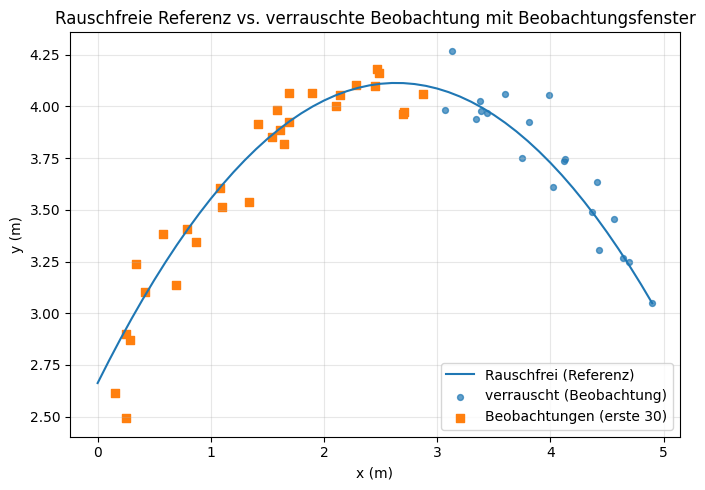

In [6]:
# === Plot: Einzelbeispiel (Clean vs. Noisy) + Beobachtungsfenster ===
# Wähle ein Beispiel (zufällig, aber reproduzierbar über SEED)
example = per_throw.sample(1, random_state=SEED).iloc[0]
wurf_id = int(example["wurf_id"])
label = int(example["label"])

g = df[df["wurf_id"] == wurf_id].sort_values("t").reset_index(drop=True)

n_obs = 30
n_obs = min(n_obs, len(g))

plt.figure(figsize=(7, 5))

# (i) rauschfreie Trajektorie als Kurve
plt.plot(g["x_clean"].values, g["y_clean"].values, label="Rauschfrei (Referenz)")

# (ii) verrauschte Stützstellen
plt.scatter(
    g["x_noisy"].values,
    g["y_noisy"].values,
    s=18,
    alpha=0.7,
    label="verrauscht (Beobachtung)",
)

# Markierung des Beobachtungspräfix (erste n_obs Punkte)
plt.scatter(
    g.loc[: n_obs - 1, "x_noisy"].values,
    g.loc[: n_obs - 1, "y_noisy"].values,
    s=40,
    marker="s",
    label=f"Beobachtungen (erste {n_obs})",
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Rauschfreie Referenz vs. verrauschte Beobachtung mit Beobachtungsfenster")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4) Modell: Encoder → (θ,v0) + Decoder (x,y) + Klassifikations-Head

In [7]:
class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 128, depth: int = 3, dropout: float = 0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.Tanh()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class AmortizedPINNClassifier(nn.Module):
    """
    Encoder (GRU) ueber beobachtete Sequenz -> Latent z.
    Heads: theta, v0, Klassifikation.
    Decoder: amortisiertes PINN, bekommt KEIN T/t_max, sondern
    - normierte Zeit t_n
    - log_denom = log(t_obs_max - t_min) als Skalierungskontext
    """
    def __init__(
        self,
        enc_hidden: int = 128,
        z_dim: int = 128,
        dec_hidden: int = 128,
        num_classes: int = 3,
        theta_min: float = 0.5,
        theta_max: float = 1.2,
        v0_min: float = 0.0
    ):
        super().__init__()
        self.theta_min = theta_min
        self.theta_max = theta_max
        self.v0_min = v0_min

        # Encoder input: (t_n, x, y)
        self.in_proj = nn.Linear(3, enc_hidden)
        self.gru = nn.GRU(input_size=enc_hidden, hidden_size=enc_hidden, batch_first=True)
        self.to_z = nn.Linear(enc_hidden, z_dim)

        self.theta_head = MLP(z_dim, 1, hidden=128, depth=2)
        self.v0_head    = MLP(z_dim, 1, hidden=128, depth=2)

        # Decoder input: z + (t_n, log_denom)
        self.decoder = MLP(z_dim + 2, 2, hidden=dec_hidden, depth=3)

        self.classifier = MLP(z_dim + 2, num_classes, hidden=128, depth=2, dropout=0.1)

    def encode(self, t_n_obs, xy_obs):
        inp = torch.cat([t_n_obs.unsqueeze(-1), xy_obs], dim=-1)  # (B,n,3)
        h = torch.tanh(self.in_proj(inp))
        _, hT = self.gru(h)  # (1,B,H)
        z = self.to_z(hT.squeeze(0))
        return z

    def predict_params(self, z):
        theta_raw = self.theta_head(z).squeeze(-1)
        v0_raw = self.v0_head(z).squeeze(-1)
        theta = self.theta_min + (self.theta_max - self.theta_min) * torch.sigmoid(theta_raw)
        v0 = self.v0_min + F.softplus(v0_raw)
        return theta, v0

    def decode_traj(self, z, t_n, log_denom):
        B, N = t_n.shape
        logd = log_denom.unsqueeze(1).expand(-1, N)  # [B,N]
        inp = torch.cat([
            z.unsqueeze(1).expand(-1, N, -1),
            t_n.unsqueeze(-1),
            logd.unsqueeze(-1),
        ], dim=-1)
        return self.decoder(inp)

    def forward(self, t_n_obs, xy_obs, t_n_query, log_denom):
        z = self.encode(t_n_obs, xy_obs)
        theta, v0 = self.predict_params(z)
        xy_hat = self.decode_traj(z, t_n_query, log_denom)
        logits = self.classifier(torch.cat([z, theta.unsqueeze(-1), v0.unsqueeze(-1)], dim=-1))
        return {"z": z, "theta": theta, "v0": v0, "xy_hat": xy_hat, "logits": logits}

model = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)
sum(p.numel() for p in model.parameters())

266119

## 5) Loss: Daten + Physik + IC + Klassifikation (+ Param-Supervision)

In [8]:
G = 9.81
H_RIM = 3.048  # 10 ft in meters
import math

def normalize_time(t, t_min, denom):
    # t: [B,N] oder [B]
    if t.dim() == 1:
        return (t - t_min) / denom
    return (t - t_min.unsqueeze(1)) / denom.unsqueeze(1)

def denormalize_time(t_n, t_min, denom):
    # t_n: [B,N]
    return t_min.unsqueeze(1) + t_n * denom.unsqueeze(1)

def time_to_height(theta, v0, y0, h=H_RIM, g=G, eps=1e-9):
    """
    Liefert t_hit_rel (>=0) relativ zu t_min, so dass:
      y(t_rel) = y0 + v0*sin(theta)*t_rel - 0.5*g*t_rel^2 = h
    plus valid-Flag (Diskriminante > 0 und t_hit > 0).
    """
    a = 0.5 * g
    b = -v0 * torch.sin(theta)
    c = h - y0

    disc = b*b - 4*a*c
    disc_clamped = torch.clamp(disc, min=0.0)
    sqrt_disc = torch.sqrt(disc_clamped + eps)

    t1 = (-b - sqrt_disc) / (2*a)
    t2 = (-b + sqrt_disc) / (2*a)

    # spaetere Loesung (typisch Abstieg)
    t_hit = torch.maximum(t1, t2)
    valid = (disc > 0) & (t_hit > 0)
    return t_hit, valid

def make_query_times_until_rim_height(
    t_min, t_obs_max, denom, theta, v0, y0,
    dt, h_rim=H_RIM,
    t_end_min_offset=0.0,
    t_end_max_offset=3.0
):
    """
    Erzeugt Query-Zeitpunkte (physikalische Zeit) von t_min bis zur (modellbasierten) Zeit,
    zu der y(t) die Korbhöhe h_rim erreicht (spätere Lösung, typ. Abstieg).
    Wichtig: Es wird kein t_full benötigt -> kein Zukunftswissen über Sequenzende.

    Erwartet B=1 (Tensor-Skalare als Shape [1]).
    """
    # robustes dt
    dt = float(dt) if dt is not None else 0.02
    dt = max(dt, 1e-4)

    t_hit_rel, valid = time_to_height(theta, v0, y0, h=h_rim)
    t_hit_abs = t_min + t_hit_rel

    t_end_raw = torch.where(valid, t_hit_abs, t_obs_max + t_end_max_offset)
    t_end = torch.clamp(
        t_end_raw,
        min=t_obs_max + t_end_min_offset,
        max=t_obs_max + t_end_max_offset
    )

    # grid <= t_end, plus ggf. exakter Endpunkt
    t_min_val = float(t_min.item())
    t_end_val = float(t_end.item())

    N = int(math.floor((t_end_val - t_min_val) / dt)) + 1
    N = max(N, 2)
    t = t_min_val + torch.arange(N, device=t_min.device, dtype=t_min.dtype) * dt

    # keine Überschreitung: ggf. letzten Punkt auf t_end setzen oder t_end anhängen
    if float(t[-1].item()) > t_end_val + 1e-9:
        t[-1] = t_end.squeeze()
    elif float(t[-1].item()) < t_end_val - 1e-9:
        t = torch.cat([t, t_end.squeeze().unsqueeze(0)], dim=0)

    return t.unsqueeze(0)  # [1,N]


def trim_prediction_at_rim_height(t_query_1d, xy_hat_2d, h_rim=H_RIM, eps=1e-9):
    """
    Schneidet die Vorhersage so ab, dass sie maximal bis zur Korbhöhe reicht.
    Falls ein Schnitt zwischen zwei Punkten liegt, wird linear auf y=h_rim interpoliert.

    t_query_1d: [N]
    xy_hat_2d:  [N,2]
    """
    y = xy_hat_2d[:, 1]
    above = y >= (h_rim - eps)

    if not torch.any(above):
        return t_query_1d, xy_hat_2d

    last_above = int(torch.where(above)[0][-1].item())
    if last_above >= (len(y) - 1):
        return t_query_1d[: last_above + 1], xy_hat_2d[: last_above + 1]

    # Interpolation zwischen last_above und next
    y1, y2 = y[last_above], y[last_above + 1]
    dy = (y2 - y1)
    if torch.abs(dy) < 1e-12:
        return t_query_1d[: last_above + 1], xy_hat_2d[: last_above + 1]

    alpha = (h_rim - y1) / dy
    alpha = torch.clamp(alpha, 0.0, 1.0)

    x1, x2 = xy_hat_2d[last_above, 0], xy_hat_2d[last_above + 1, 0]
    t1, t2 = t_query_1d[last_above], t_query_1d[last_above + 1]

    x_cross = x1 + alpha * (x2 - x1)
    t_cross = t1 + alpha * (t2 - t1)

    xy_cross = torch.stack([
        x_cross,
        torch.tensor(h_rim, device=xy_hat_2d.device, dtype=xy_hat_2d.dtype)
    ], dim=0)

    t_new = torch.cat([t_query_1d[: last_above + 1], t_cross.unsqueeze(0)], dim=0)
    xy_new = torch.cat([xy_hat_2d[: last_above + 1], xy_cross.unsqueeze(0)], dim=0)

    return t_new, xy_new



def physics_residuals_time_normed(out, t_n, t_min, denom):
    """
    out["xy_hat"] ist bei t_n ausgewertet (t_n hat requires_grad=True).
    Autograd liefert Ableitungen nach t_n -> per Kettenregel nach phys. Zeit umrechnen.
    """
    xy = out["xy_hat"]
    x = xy[..., 0]
    y = xy[..., 1]
    theta = out["theta"]
    v0 = out["v0"]

    ones = torch.ones_like(x)
    dx_dt_n = torch.autograd.grad(x, t_n, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
    dy_dt_n = torch.autograd.grad(y, t_n, grad_outputs=ones, create_graph=True, retain_graph=True)[0]

    # Kettenregel: t_n = (t - t_min)/denom  => dt_n/dt = 1/denom
    dx_dt = dx_dt_n / denom.unsqueeze(1)
    dy_dt = dy_dt_n / denom.unsqueeze(1)

    # Physik nutzt t_rel = t - t_min (Zeit seit Beginn der Observations)
    t_phys = denormalize_time(t_n, t_min, denom)
    t_rel = t_phys - t_min.unsqueeze(1)

    target_dx = v0.unsqueeze(1) * torch.cos(theta).unsqueeze(1)
    target_dy = v0.unsqueeze(1) * torch.sin(theta).unsqueeze(1) - G * t_rel

    rx = dx_dt - target_dx
    ry = dy_dt - target_dy
    return rx, ry

def compute_losses(
    batch, model,
    n_col=64,
    h_rim=H_RIM,
    t_end_min_offset=0.25,
    t_end_max_offset=3.0,
    w_data=15.0, w_phys=0.5, w_ic=10.0, w_cls=0.01
):
    t_obs   = batch["t_obs"].to(device)      # [B,n_obs]
    xy_obs  = batch["xy_obs"].to(device)     # [B,n_obs,2]
    label   = batch["label"].to(device)

    t_min   = batch["t_min"].to(device)          # [B]
    t_obs_max = batch["t_obs_max"].to(device)    # [B]
    denom   = batch["denom"].to(device).clamp_min(1e-4)  # [B]
    log_denom = torch.log(denom)

    # normalisierte Zeit: Beobachtungen in [0,1], Zukunft bei >1
    t_n_obs = normalize_time(t_obs, t_min, denom)

    # Data + Classification auf Beobachtungen
    out_obs = model(t_n_obs, xy_obs, t_n_obs, log_denom)
    data_loss = F.mse_loss(out_obs["xy_hat"], xy_obs)

    # IC bei t_n=0 (t=t_min): passt den ersten Punkt an (robuster als x(0)=0 Annahme)
    t0_n = torch.zeros((t_obs.shape[0], 1), device=device)
    out0 = model(t_n_obs, xy_obs, t0_n, log_denom)
    ic_loss = F.mse_loss(out0["xy_hat"].squeeze(1), xy_obs[:, 0, :])

    # Dynamisches Collocation-Ende bis Korbhöhe (ballistisch) + Sicherheitsfenster
    y0 = xy_obs[:, 0, 1]  # Starthöhe aus Beobachtung (kein Oracle)
    theta = out_obs["theta"]
    v0 = out_obs["v0"]

    t_hit_rel, valid = time_to_height(theta, v0, y0, h=h_rim)
    t_hit_abs = t_min + t_hit_rel

    t_end_raw = torch.where(valid, t_hit_abs, t_obs_max + t_end_max_offset)
    t_end = torch.clamp(
        t_end_raw,
        min=t_obs_max + t_end_min_offset,
        max=t_obs_max + t_end_max_offset
    ).detach()  # detach gegen "Cheating" ueber t_end

    # Collocation-Zeiten pro Sample: t ~ U(t_min, t_end)
    B = t_obs.shape[0]
    u = torch.rand((B, n_col), device=device)
    t_col = t_min.unsqueeze(1) + u * (t_end.unsqueeze(1) - t_min.unsqueeze(1))  # [B,n_col]
    t_n_col = normalize_time(t_col, t_min, denom)                                # [B,n_col]
    t_n_col.requires_grad_(True)

    out_col = model(t_n_obs, xy_obs, t_n_col, log_denom)
    rx, ry = physics_residuals_time_normed(out_col, t_n_col, t_min, denom)
    phys_loss = rx.pow(2).mean() + ry.pow(2).mean()

    # Classification
    cls_loss = F.cross_entropy(out_obs["logits"], label)

    total = w_data*data_loss + w_ic*ic_loss + w_phys*phys_loss + w_cls*cls_loss

    return total, {
        "total": total.detach().item(),
        "data": data_loss.detach().item(),
        "ic": ic_loss.detach().item(),
        "phys": phys_loss.detach().item(),
        "cls": cls_loss.detach().item(),
    }

def compute_mse_obs_future(pred_xy, gt_xy, n_obs: int):
    """
    pred_xy, gt_xy: Tensor [B, T, 2]
    """
    mse_obs = F.mse_loss(pred_xy[:, :n_obs, :], gt_xy[:, :n_obs, :], reduction="mean")
    mse_future = F.mse_loss(pred_xy[:, n_obs:, :], gt_xy[:, n_obs:, :], reduction="mean")
    return mse_obs.item(), mse_future.item()

## 6) Training (mit Early Stopping)

In [9]:
def run_epoch(loader, model, optimizer=None, **loss_kwargs):
    is_train = optimizer is not None
    model.train(is_train)
    meters = {"total":0, "data":0, "ic":0, "phys":0, "cls":0}
    n_batches = 0

    for batch in loader:
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        total, parts = compute_losses(batch, model, **loss_kwargs)

        if is_train:
            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        for k in meters:
            meters[k] += parts[k]
        n_batches += 1

    for k in meters:
        meters[k] /= max(n_batches,1)
    return meters

def train_model(model, train_loader, val_loader, epochs=800, lr=2e-3, patience=50, **loss_kwargs):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best = float("inf")
    best_state = None
    bad = 0
    history = {"train":[], "val":[]}

    for epoch in range(1, epochs+1):
        tr = run_epoch(train_loader, model, optimizer=optimizer, **loss_kwargs)
        va = run_epoch(val_loader, model, optimizer=None, **loss_kwargs)
        history["train"].append(tr)
        history["val"].append(va)

        if va["total"] < best - 1e-5:
            best = va["total"]
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | train {tr['total']:.4f} | val {va['total']:.4f} "
                  f"(data {va['data']:.4f}, phys {va['phys']:.4f}, cls {va['cls']:.4f})")

        if bad >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=800,
    lr=2e-3,
    patience=50,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

Epoch    1 | train 447.4556 | val 374.5834 (data 3.4162, phys 349.0641, cls 1.0956)
Epoch   10 | train 12.5547 | val 12.5955 (data 0.9240, phys 6.9346, cls 1.1068)
Epoch   20 | train 10.4174 | val 10.6818 (data 0.9115, phys 5.2969, cls 1.0973)
Epoch   30 | train 14.0018 | val 15.7156 (data 0.4157, phys 5.2597, cls 1.1066)
Epoch   40 | train 6.0432 | val 5.7065 (data 0.1379, phys 4.6028, cls 1.0905)
Epoch   50 | train 7.5664 | val 7.4248 (data 0.2169, phys 5.5643, cls 1.0911)
Epoch   60 | train 4.7593 | val 4.6899 (data 0.1631, phys 3.1034, cls 1.0887)
Epoch   70 | train 3.6406 | val 3.9573 (data 0.2286, phys 1.9857, cls 1.0461)
Epoch   80 | train 2.1322 | val 2.2780 (data 0.1733, phys 0.7231, cls 0.9171)
Epoch   90 | train 3.2740 | val 2.1055 (data 0.1035, phys 1.2967, cls 1.2354)
Epoch  100 | train 2.0152 | val 1.0274 (data 0.1088, phys 0.3597, cls 0.8284)
Epoch  110 | train 1.8850 | val 1.4315 (data 0.0900, phys 0.8524, cls 0.7981)
Epoch  120 | train 1.1293 | val 0.4947 (data 0.0606,

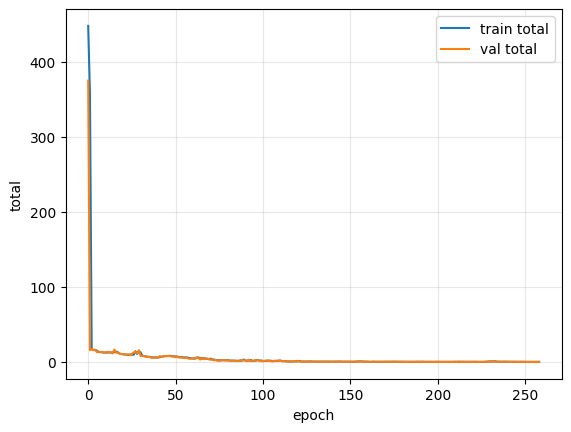

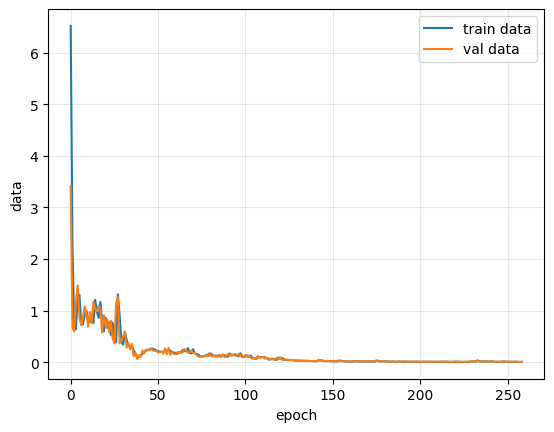

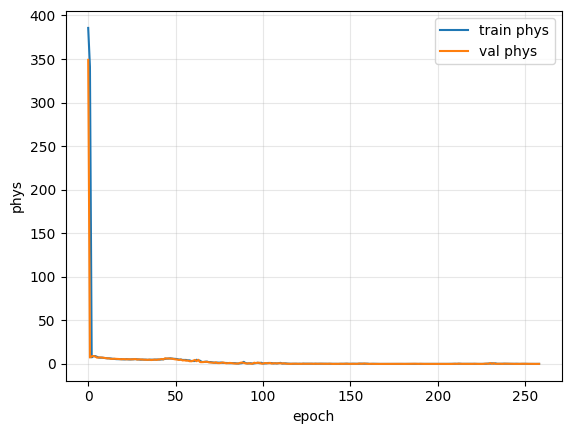

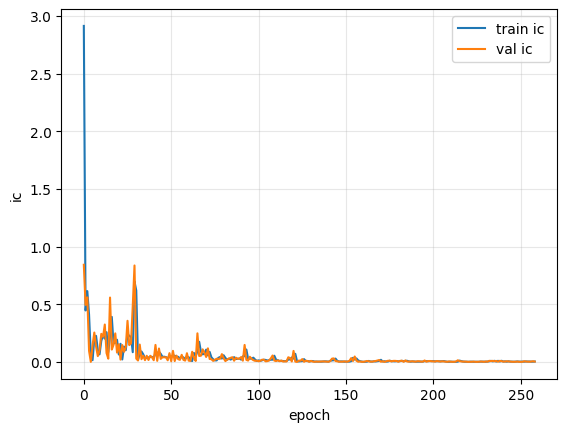

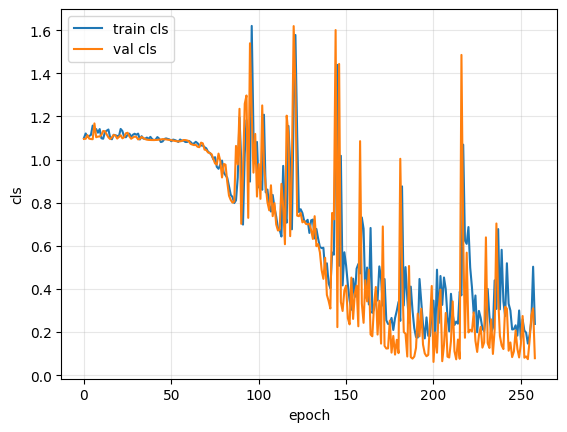

In [10]:
def plot_history(history, key="total"):
    tr = [h[key] for h in history["train"]]
    va = [h[key] for h in history["val"]]
    plt.figure()
    plt.plot(tr, label=f"train {key}")
    plt.plot(va, label=f"val {key}")
    plt.xlabel("epoch"); plt.ylabel(key); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

for k in ["total","data","phys","ic","cls"]:
    plot_history(history, k)

## 7) Evaluation auf Testset

Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

theta MAE:    0.02713 rad
v0 MAE:       0.33402 m/s


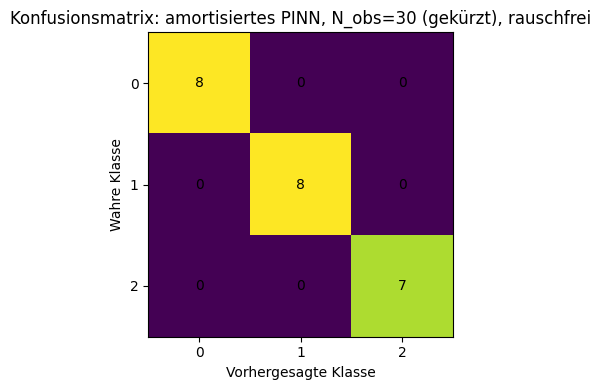

In [11]:
def plot_confusion_matrix(cm, title="Confusion Matrix", ax=None):
    """
    Plottet eine Confusion Matrix wie im Screenshot (imshow + Zahlen),
    mit frei übergebbarem Titel.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    im = ax.imshow(cm, interpolation="nearest")  # Standard-Colormap wie im Screenshot

    # Achsenbeschriftungen
    ax.set_title(title)
    ax.set_xlabel("Vorhergesagte Klasse")
    ax.set_ylabel("Wahre Klasse")

    # Ticks 0..C-1
    C = cm.shape[0]
    ax.set_xticks(np.arange(C))
    ax.set_yticks(np.arange(C))
    ax.set_xticklabels([str(i) for i in range(C)])
    ax.set_yticklabels([str(i) for i in range(C)])

    # Zahlen in die Zellen
    for i in range(C):
        for j in range(C):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", color="black")

    # verhindert abgeschnittene Achsen bei manchen Backends
    ax.set_ylim(C - 0.5, -0.5)

    fig.tight_layout()
    return fig, ax


@torch.no_grad()
def evaluate(loader, model, titel):
    model.eval()
    y_true, y_pred = [], []
    theta_true, theta_pred = [], []
    v0_true, v0_pred = [], []

    mse_obs_list = []
    mse_future_list = []
    mse_full_list = []

    for batch in loader:
        t_obs  = batch["t_obs"].to(device)      # [B,n_obs]
        xy_obs = batch["xy_obs"].to(device)     # [B,n_obs,2]
        t_full = batch["t_full"].to(device)     # [B,M]
        xy_full = batch["xy_full"].to(device)   # [B,M,2]

        t_min = batch["t_min"].to(device)       # [B]
        denom = batch["denom"].to(device).clamp_min(1e-4)  # [B]
        log_denom = torch.log(denom)

        t_n_obs  = normalize_time(t_obs, t_min, denom)     # [B,n_obs]
        t_n_full = normalize_time(t_full, t_min, denom)    # [B,M]

        out = model(t_n_obs, xy_obs, t_n_full, log_denom)

        pred = out["logits"].argmax(dim=1).cpu().numpy()
        y_pred.extend(pred.tolist())
        y_true.extend(batch["label"].numpy().tolist())

        theta_pred.extend(out["theta"].cpu().numpy().tolist())
        v0_pred.extend(out["v0"].cpu().numpy().tolist())
        theta_true.extend(batch["theta"].numpy().tolist())
        v0_true.extend(batch["v0"].numpy().tolist())

        mse_full = F.mse_loss(out["xy_hat"], xy_full, reduction="mean").item()
        mse_full_list.append(mse_full)

        mse_obs, mse_future = compute_mse_obs_future(out["xy_hat"], xy_full, n_obs=n_obs)
        mse_obs_list.append(mse_obs)
        mse_future_list.append(mse_future)

    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)
    print("\nClassification report:\n", classification_report(y_true, y_pred))
    plot_confusion_matrix(
        confusion_matrix(y_true, y_pred),
        title=titel
    )

    theta_mae = np.mean(np.abs(np.array(theta_pred) - np.array(theta_true)))
    v0_mae = np.mean(np.abs(np.array(v0_pred) - np.array(v0_true)))
    print(f"theta MAE:    {theta_mae:.5f} rad")
    print(f"v0 MAE:       {v0_mae:.5f} m/s")
    # print(f"traj MSE full:{np.mean(mse_full_list):.6f}")
    # print(f"traj MSE obs: {np.mean(mse_obs_list):.6f}")
    # print(f"traj MSE fut: {np.nanmean(mse_future_list):.6f}")


evaluate(
    test_loader,
    model,
    titel="Konfusionsmatrix: amortisiertes PINN, N_obs=30 (gekürzt), rauschfrei",
)

## 8) Demo: Rekonstruktion + Klassifikation für einen einzelnen Wurf

=== Trajektorienfehler vs. clean Ground Truth ===
MSE full:   0.02231212
MSE obs:    0.00601603
MSE future: 0.04675624
Wurf 1 | true label=1 | pred label=1
theta true=0.8891, pred=0.8772
v0    true=6.6624, pred=6.6815


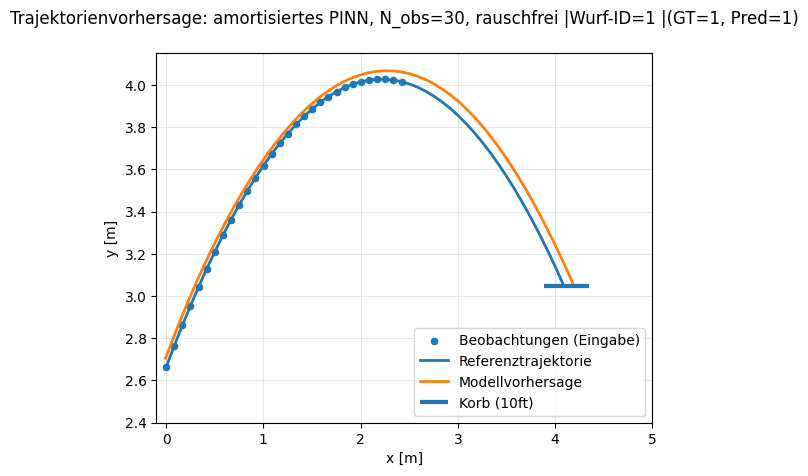

In [10]:
@torch.no_grad()
def demo_reconstruction(model, ds, n_obs=None, idx=0):
    s = ds[idx]
    wurf_id = s["wurf_id"]

    t_obs = s["t_obs"].unsqueeze(0).to(device)
    xy_obs = s["xy_obs"].unsqueeze(0).to(device)

    t_min = s["t_min"].unsqueeze(0).to(device)
    t_obs_max = s["t_obs_max"].unsqueeze(0).to(device)
    denom = s["denom"].unsqueeze(0).to(device).clamp_min(1e-4)
    log_denom = torch.log(denom)

    t_n_obs = normalize_time(t_obs, t_min, denom)

    # Inferenz von (theta, v0) ausschließlich aus Beobachtungen
    out_obs = model(t_n_obs, xy_obs, t_n_obs, log_denom)
    theta_pred = out_obs["theta"]
    v0_pred = out_obs["v0"]

    # Query-Zeiten bis Korbhöhe (kein t_full als Input)
    if t_obs.shape[1] > 1:
        dt = float((t_obs[:, 1:] - t_obs[:, :-1]).mean().item())
    else:
        dt = 0.02

    y0 = xy_obs[:, 0, 1]
    t_query = make_query_times_until_rim_height(
        t_min=t_min, t_obs_max=t_obs_max, denom=denom,
        theta=theta_pred, v0=v0_pred, y0=y0,
        dt=dt, h_rim=H_RIM
    )  # [1,N]

    t_n_query = normalize_time(t_query, t_min, denom)

    out = model(t_n_obs, xy_obs, t_n_query, log_denom)
    xy_hat_t = out["xy_hat"].squeeze(0)  # [N,2]
    t_q_1d = t_query.squeeze(0)

    # Hartes Abschneiden bei Korbhöhe (verhindert unnötige Extrapolation unterhalb der Ebene)
    t_q_trim, xy_hat_trim = trim_prediction_at_rim_height(t_q_1d, xy_hat_t, h_rim=H_RIM)

    xy_hat = xy_hat_trim.detach().cpu().numpy()
    xy_obs_np = s["xy_obs"].numpy()

    # Ground Truth nur für Visualisierung (kein Input)
    xy_full = s["xy_full"].numpy()

    theta_gt = float(s["theta"].item())
    v0_gt = float(s["v0"].item())
    theta_pred_val = float(theta_pred.item())
    v0_pred_val = float(v0_pred.item())

    theta_pred_deg = math.degrees(theta_pred_val)
    theta_gt_deg = math.degrees(theta_gt)

    pred_label = int(out["logits"].argmax(dim=1).item())
    print(f"Wurf {wurf_id} | true label={s['label'].item()} | pred label={pred_label}")
    print(f"theta true={theta_gt:.4f}, pred={theta_pred_val:.4f}")
    print(f"v0    true={v0_gt:.4f}, pred={v0_pred_val:.4f}")

    plt.figure()
    plt.scatter(xy_obs_np[:, 0], xy_obs_np[:, 1], s=20, label="Beobachtungen (Eingabe)")
    plt.plot(xy_full[:, 0], xy_full[:, 1], linewidth=2, label="Referenztrajektorie")
    plt.plot(xy_hat[:, 0], xy_hat[:, 1], linewidth=2, label="Modellvorhersage")

    plt.hlines(y=3.048, xmin=4.115 - 0.2286, xmax=4.115 + 0.2286, linewidth=3, label="Korb (10ft)")

    plt.title(
        f"Trajektorienvorhersage: amortisiertes PINN, N_obs={n_obs}, rauschfrei |"
        f"Wurf-ID={wurf_id} |"
        f"(GT={int(s['label'].item())}, Pred={pred_label})\n"
        # f"theta true={theta_gt_deg:.2f}°, pred={theta_pred_deg:.2f}° | v0 true={v0_gt:.2f}, pred={v0_pred_val:.2f}"
    )
    plt.xlabel("x [m]"); plt.ylabel("y [m]"); plt.legend(); plt.grid(True, alpha=0.3)
    plt.xlim(-0.1, 5)
    plt.ylim(2.4, 4.15)
    plt.show()

import math
import numpy as np
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def demo_reconstruction_noisy_vs_clean(model, ds_noisy, ds_clean, n_obs=None, idx=0):
    """
    ds_noisy: Dataset mit use_noisy=True (Inputs sind noisy)
    ds_clean: Dataset mit use_noisy=False (GT-Trajektorie ist clean)
    """
    # --- noisy sample ---
    sN = ds_noisy[idx]
    wurf_id = sN["wurf_id"]

    # --- find matching clean sample by wurf_id ---
    if not hasattr(demo_reconstruction_noisy_vs_clean, "_clean_index") or getattr(
        demo_reconstruction_noisy_vs_clean, "_clean_index_ds_id", None
    ) != id(ds_clean):
        clean_index = {}
        for j in range(len(ds_clean)):
            wj = ds_clean[j]["wurf_id"]
            clean_index[wj] = j
        demo_reconstruction_noisy_vs_clean._clean_index = clean_index
        demo_reconstruction_noisy_vs_clean._clean_index_ds_id = id(ds_clean)

    clean_index = demo_reconstruction_noisy_vs_clean._clean_index
    if wurf_id not in clean_index:
        raise KeyError(f"wurf_id={wurf_id} nicht im ds_clean gefunden. Prüfe Split/IDs.")

    sC = ds_clean[clean_index[wurf_id]]

    # --- model forward: nur noisy Beobachtungen, Query-Zeiten dynamisch bis Korbhöhe ---
    t_obs = sN["t_obs"].unsqueeze(0).to(device)
    xy_obs = sN["xy_obs"].unsqueeze(0).to(device)

    t_min = sN["t_min"].unsqueeze(0).to(device)
    t_obs_max = sN["t_obs_max"].unsqueeze(0).to(device)
    denom = sN["denom"].unsqueeze(0).to(device).clamp_min(1e-4)
    log_denom = torch.log(denom)

    t_n_obs = normalize_time(t_obs, t_min, denom)

    # Parameter aus Beobachtungen (kein t_full)
    out_obs = model(t_n_obs, xy_obs, t_n_obs, log_denom)
    theta_pred = out_obs["theta"]
    v0_pred = out_obs["v0"]

    if t_obs.shape[1] > 1:
        dt = float((t_obs[:, 1:] - t_obs[:, :-1]).mean().item())
    else:
        dt = 0.02

    y0 = xy_obs[:, 0, 1]
    t_query = make_query_times_until_rim_height(
        t_min=t_min, t_obs_max=t_obs_max, denom=denom,
        theta=theta_pred, v0=v0_pred, y0=y0,
        dt=dt, h_rim=H_RIM
    )  # [1,N]
    t_n_query = normalize_time(t_query, t_min, denom)

    out = model(t_n_obs, xy_obs, t_n_query, log_denom)
    xy_hat_t = out["xy_hat"].squeeze(0)  # [N,2]
    t_q_1d = t_query.squeeze(0)

    # Abschneiden bei Korbhöhe
    t_q_trim, xy_hat_trim = trim_prediction_at_rim_height(t_q_1d, xy_hat_t, h_rim=H_RIM)
    xy_hat = xy_hat_trim.detach().cpu().numpy()

    # --- arrays for plotting ---
    xy_obs_np = sN["xy_obs"].numpy()           # noisy obs
    xy_gt_clean = sC["xy_full"].numpy()        # clean GT full (nur Plot)

    theta_gt = float(sC["theta"].item())
    v0_gt = float(sC["v0"].item())
    theta_pred_val = float(theta_pred.item())
    v0_pred_val = float(v0_pred.item())

    theta_pred_deg = math.degrees(theta_pred_val)
    theta_gt_deg = math.degrees(theta_gt)

    pred_label = int(out["logits"].argmax(dim=1).item())

    plt.figure()
    plt.scatter(xy_obs_np[:, 0], xy_obs_np[:, 1], s=20, label="Beobachtungen (Eingabe)")
    plt.plot(xy_gt_clean[:, 0], xy_gt_clean[:, 1], linewidth=2, label="Referenztrajektorie")
    plt.plot(xy_hat[:, 0], xy_hat[:, 1], linewidth=2, label="Modellvorhersage")

    plt.hlines(y=3.048, xmin=4.115 - 0.2286, xmax=4.115 + 0.2286, linewidth=3, label="Korb (10ft)")

    plt.title(
        f"Trajektorienvorhersage: amortisiertes PINN, N_obs={n_obs}, verrauscht |"
        f"Wurf-ID={wurf_id} |"
        f"(GT={int(sC['label'].item())}, Pred={pred_label})\n"
        # f"theta true={theta_gt_deg:.2f}°, pred={theta_pred_deg:.2f}° | v0 true={v0_gt:.2f}, pred={v0_pred_val:.2f}"
    )
    plt.xlabel("x [m]"); plt.ylabel("y [m]"); plt.legend(); plt.grid(True, alpha=0.3)
    plt.xlim(-0.1, 5)
    plt.ylim(2.4, 4.15)
    plt.show()


@torch.no_grad()
def evaluate_trajectory_mse_vs_clean_gt(
    loader_obs,
    ds_clean,
    model,
    n_obs: int,
    compute_obs_future: bool = True,
):
    """
    Berechnet den mittleren quadratischen Fehler (MSE) der vorhergesagten Trajektorie
    gegen die *clean* Ground-Truth-Trajektorie, ohne dass das Modell clean-Daten sieht.

    - loader_obs: DataLoader (typisch: noisy), liefert Inputs und Zeiten (t_obs, t_full, ...)
                 sowie wurf_id als Liste (collate_fn).
    - ds_clean: FreeThrowDataset(use_noisy=False) mit identischen wurf_id im selben Split.
               Wird NUR für die Auswertung genutzt (xy_full clean).
    - model: AmortizedPINNClassifier
    - n_obs: Länge des Beobachtungsfensters

    Rückgabe: dict mit mse_full (+ optional mse_obs, mse_future)
    """
    model.eval()

    # Cache: wurf_id -> clean xy_full (CPU Tensor)
    if (not hasattr(evaluate_trajectory_mse_vs_clean_gt, "_clean_cache")) or (
        getattr(evaluate_trajectory_mse_vs_clean_gt, "_clean_cache_ds_id", None) != id(ds_clean)
    ):
        cache = {}
        for i in range(len(ds_clean)):
            s = ds_clean[i]
            cache[int(s["wurf_id"])] = s["xy_full"].detach().cpu()  # [M,2]
        evaluate_trajectory_mse_vs_clean_gt._clean_cache = cache
        evaluate_trajectory_mse_vs_clean_gt._clean_cache_ds_id = id(ds_clean)

    clean_cache = evaluate_trajectory_mse_vs_clean_gt._clean_cache

    # Wir akkumulieren SSE und numel, damit der Gesamt-MSE korrekt über alle Punkte gemittelt wird.
    sse_full = 0.0
    n_full = 0

    sse_obs = 0.0
    n_obs_count = 0
    sse_future = 0.0
    n_future_count = 0

    for batch in loader_obs:
        # Inputs (noisy oder clean – je nachdem wie loader_obs gebaut ist)
        t_obs  = batch["t_obs"].to(device)      # [B,n_obs]
        xy_obs = batch["xy_obs"].to(device)     # [B,n_obs,2]
        t_full = batch["t_full"].to(device)     # [B,M]

        t_min  = batch["t_min"].to(device)      # [B]
        denom  = batch["denom"].to(device).clamp_min(1e-4)  # [B]
        log_denom = torch.log(denom)

        t_n_obs  = normalize_time(t_obs,  t_min, denom)     # [B,n_obs]
        t_n_full = normalize_time(t_full, t_min, denom)     # [B,M]

        # Modellvorhersage NUR aus Beobachtungen (kein clean xy_full wird ins Modell gegeben)
        out = model(t_n_obs, xy_obs, t_n_full, log_denom)
        pred_xy = out["xy_hat"]  # [B,M,2]

        # Clean-GT passend zu den wurf_id holen (nur Auswertung)
        ids = batch["wurf_id"]   # Liste der Länge B
        gt_list = []
        for wid in ids:
            wid_int = int(wid)
            if wid_int not in clean_cache:
                raise KeyError(f"wurf_id={wid_int} nicht im ds_clean gefunden. Prüfe Split/IDs.")
            gt_list.append(clean_cache[wid_int])
        gt_xy = torch.stack(gt_list, dim=0).to(device)  # [B,M,2]

        # Full MSE (über alle Koordinaten und Zeitpunkte)
        diff = pred_xy - gt_xy
        sse_full += float((diff * diff).sum().item())
        n_full += diff.numel()

        if compute_obs_future:
            diff_obs = diff[:, :n_obs, :]
            diff_fut = diff[:, n_obs:, :]

            sse_obs += float((diff_obs * diff_obs).sum().item())
            n_obs_count += diff_obs.numel()

            # Falls n_obs == M, ist future leer -> numel = 0
            if diff_fut.numel() > 0:
                sse_future += float((diff_fut * diff_fut).sum().item())
                n_future_count += diff_fut.numel()

    mse_full = sse_full / max(1, n_full)
    result = {"mse_full_vs_clean_gt": mse_full}

    if compute_obs_future:
        result["mse_obs_vs_clean_gt"] = sse_obs / max(1, n_obs_count)
        # Wenn future leer war, bleibt n_future_count = 0 -> NaN setzen
        result["mse_future_vs_clean_gt"] = (sse_future / n_future_count) if n_future_count > 0 else float("nan")

    print("=== Trajektorienfehler vs. clean Ground Truth ===")
    print(f"MSE full:   {result['mse_full_vs_clean_gt']:.8f}")
    if compute_obs_future:
        print(f"MSE obs:    {result['mse_obs_vs_clean_gt']:.8f}")
        print(f"MSE future: {result['mse_future_vs_clean_gt']:.8f}")

    return result

evaluate_trajectory_mse_vs_clean_gt(test_loader, ds_clean=test_ds, model=model, n_obs=30)
demo_reconstruction(model,test_ds, n_obs=30, idx=0)

## 9) Nächster Schritt: Training mit verrauschten Koordinaten

Epoch    1 | train 455.4818 | val 404.4664 (data 3.6565, phys 373.8291, cls 1.0997)
Epoch   10 | train 38.7527 | val 29.9247 (data 0.6425, phys 23.1188, cls 1.1256)
Epoch   20 | train 11.9649 | val 10.7632 (data 0.6866, phys 5.8798, cls 1.2112)
Epoch   30 | train 13.8738 | val 32.1909 (data 3.0305, phys 5.7431, cls 1.1321)
Epoch   40 | train 7.4861 | val 7.4343 (data 0.3915, phys 5.0013, cls 1.1022)
Epoch   50 | train 8.2911 | val 8.2520 (data 0.2425, phys 5.8483, cls 1.1013)
Epoch   60 | train 7.9726 | val 7.8573 (data 0.1640, phys 6.5038, cls 1.0942)
Epoch   70 | train 7.8193 | val 9.3075 (data 0.4799, phys 4.4230, cls 1.0867)
Epoch   80 | train 6.4116 | val 4.2981 (data 0.1785, phys 2.4687, cls 1.0724)
Epoch   90 | train 3.4388 | val 2.6041 (data 0.1143, phys 1.7732, cls 0.9837)
Epoch  100 | train 1.7173 | val 1.5532 (data 0.1066, phys 0.5830, cls 0.9137)
Epoch  110 | train 1.3413 | val 1.2695 (data 0.1225, phys 0.4424, cls 0.5210)
Epoch  120 | train 1.7646 | val 1.1296 (data 0.0981

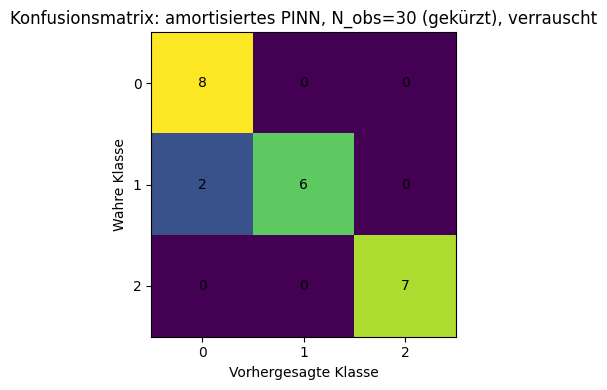

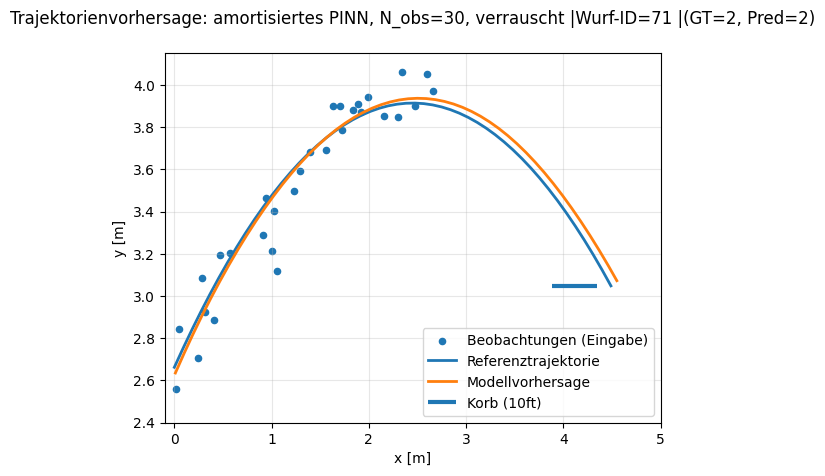

In [12]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=n_obs, use_noisy=True)
val_ds_noisy   = FreeThrowDataset(df, val_ids,   n_obs=n_obs, use_noisy=True)
test_ds_noisy  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=True)
test_ds_clean  = FreeThrowDataset(df, test_ids,  n_obs=n_obs, use_noisy=False)

train_loader_noisy = DataLoader(train_ds_noisy, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader_noisy   = DataLoader(val_ds_noisy,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader_noisy  = DataLoader(test_ds_noisy,  batch_size=64, shuffle=False, collate_fn=collate_fn)

model = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model,
    train_loader_noisy,
    val_loader_noisy,
    epochs=800,
    lr=2e-3,
    patience=50,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.1,
)

evaluate(
    test_loader_noisy,
    model,
    titel="Konfusionsmatrix: amortisiertes PINN, N_obs=30 (gekürzt), verrauscht",
)

evaluate_trajectory_mse_vs_clean_gt(test_loader_noisy, ds_clean=test_ds_clean, model=model, n_obs=30)
demo_reconstruction_noisy_vs_clean(model,test_ds_noisy, test_ds_clean, n_obs=30, idx=11)

Epoch    1 | train 539.7870 | val 501.6987 (data 4.7402, phys 469.3605, cls 1.0862)
Epoch   10 | train 28.2006 | val 30.5132 (data 2.2982, phys 17.0930, cls 1.1043)
Epoch   20 | train 23.1060 | val 21.3499 (data 0.9803, phys 12.1579, cls 1.1196)
Epoch   30 | train 22.0142 | val 20.5100 (data 1.2248, phys 12.1696, cls 1.0936)
Epoch   40 | train 16.2029 | val 20.2171 (data 0.3746, phys 11.7121, cls 1.1002)
Epoch   50 | train 16.4929 | val 14.4620 (data 0.2319, phys 11.8098, cls 1.0956)
Epoch   60 | train 15.1353 | val 19.5863 (data 0.7512, phys 11.2413, cls 1.0882)
Epoch   70 | train 14.9530 | val 17.6863 (data 0.4965, phys 13.5684, cls 1.0725)
Epoch   80 | train 11.2429 | val 9.0552 (data 0.4910, phys 5.8753, cls 0.9955)
Epoch   90 | train 3.8090 | val 4.0303 (data 0.3215, phys 1.7111, cls 0.6347)
Epoch  100 | train 4.0009 | val 3.8869 (data 0.1831, phys 2.0484, cls 0.4081)
Epoch  110 | train 3.2861 | val 3.4504 (data 0.2852, phys 1.4326, cls 0.2575)
Epoch  120 | train 2.8622 | val 2.27

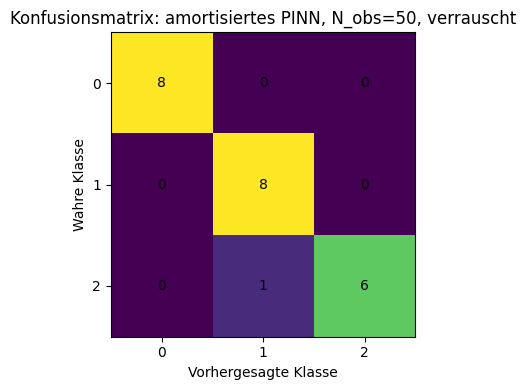

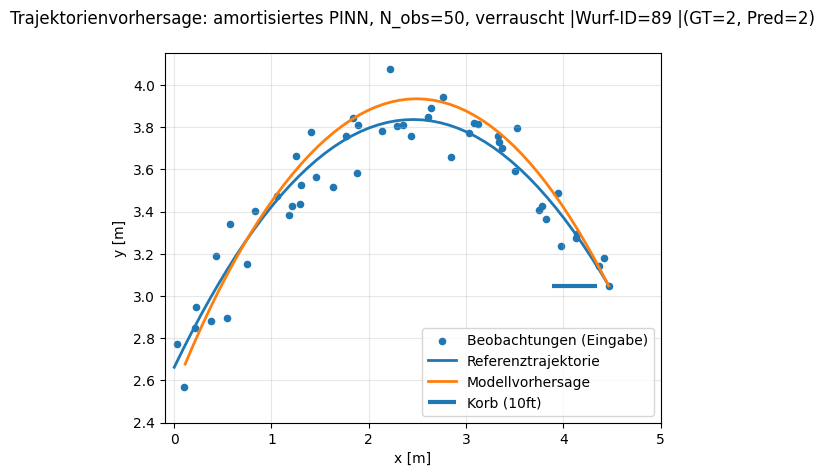

In [13]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=50, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=50, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=50, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=50, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=64, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_50 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(
    device
)

history_noisy = train_model(
    model_noisy_50,
    train_loader_noisy,
    val_loader_noisy,
    epochs=800,
    lr=2e-3,
    patience=50,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(
    test_loader_noisy,
    model_noisy_50,
    titel="Konfusionsmatrix: amortisiertes PINN, N_obs=50, verrauscht",
)

evaluate_trajectory_mse_vs_clean_gt(
    test_loader_noisy, ds_clean=test_ds_clean, model=model_noisy_50, n_obs=50
)
demo_reconstruction_noisy_vs_clean(
    model_noisy_50, test_ds_noisy, test_ds_clean, n_obs=50, idx=14
)

Epoch    1 | train 404.9155 | val 350.5413 (data 3.6078, phys 317.1618, cls 1.0919)
Epoch   10 | train 98.4365 | val 30.4720 (data 0.3852, phys 27.2585, cls 1.1011)
Epoch   20 | train 19.5603 | val 19.3068 (data 0.5173, phys 14.9506, cls 1.1042)
Epoch   30 | train 27.0298 | val 21.3419 (data 0.4579, phys 18.1259, cls 1.1015)
Epoch   40 | train 4.0271 | val 3.7225 (data 0.3551, phys 1.7911, cls 1.0990)
Epoch   50 | train 3.0523 | val 5.1411 (data 0.1171, phys 1.7116, cls 1.0998)
Epoch   60 | train 1.7927 | val 1.6643 (data 0.0637, phys 0.6674, cls 1.1009)
Epoch   70 | train 1.8914 | val 1.9899 (data 0.1678, phys 0.8455, cls 1.0929)
Epoch   80 | train 1.2904 | val 1.3546 (data 0.1020, phys 0.4833, cls 1.0516)
Epoch   90 | train 1.1331 | val 0.7326 (data 0.0741, phys 0.1575, cls 0.9802)
Epoch  100 | train 3.8722 | val 1.1987 (data 0.0709, phys 0.6042, cls 1.1179)
Epoch  110 | train 0.7499 | val 1.1503 (data 0.0752, phys 0.5714, cls 0.9636)
Epoch  120 | train 0.8234 | val 0.6973 (data 0.03

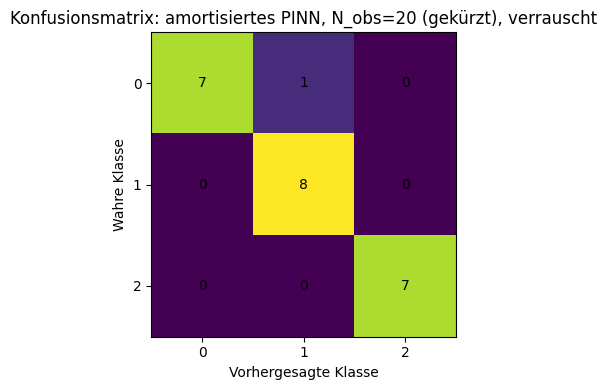

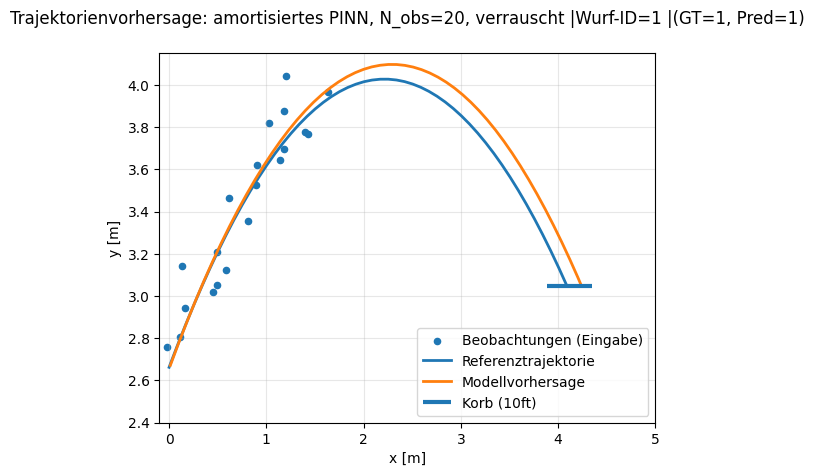

In [15]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=20, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=20, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=64, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_20 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model_noisy_20,
    train_loader_noisy,
    val_loader_noisy,
    epochs=800,
    lr=2e-3,
    patience=50,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(
    test_loader_noisy,
    model_noisy_20,
    titel="Konfusionsmatrix: amortisiertes PINN, N_obs=20 (gekürzt), verrauscht",
)

demo_reconstruction_noisy_vs_clean(model_noisy_20,test_ds_noisy, test_ds_clean, n_obs=20, idx=0)

Epoch    1 | train 401.5701 | val 342.5498 (data 3.1466, phys 313.7856, cls 1.0994)
Epoch   10 | train 7.2801 | val 6.7070 (data 0.5297, phys 3.7557, cls 1.1148)
Epoch   20 | train 6.0119 | val 5.3372 (data 0.3794, phys 3.0251, cls 1.0980)
Epoch   30 | train 4.5969 | val 4.5672 (data 0.2383, phys 2.2688, cls 1.1087)
Epoch   40 | train 2.1613 | val 2.0920 (data 0.0978, phys 1.0721, cls 1.0987)
Epoch   50 | train 2.0152 | val 2.1119 (data 0.0598, phys 1.5217, cls 1.0999)
Epoch   60 | train 1.9364 | val 1.7923 (data 0.0662, phys 1.3236, cls 1.0935)
Epoch   70 | train 1.9096 | val 2.8006 (data 0.0574, phys 2.3839, cls 1.0687)
Epoch   80 | train 1.0189 | val 1.3452 (data 0.0682, phys 0.6162, cls 1.0496)
Epoch   90 | train 1.1983 | val 0.8529 (data 0.0644, phys 0.2447, cls 0.9437)
Epoch  100 | train 0.6554 | val 0.8863 (data 0.0467, phys 0.5797, cls 0.8062)
Epoch  110 | train 0.6341 | val 0.4518 (data 0.0303, phys 0.2294, cls 1.0509)
Epoch  120 | train 0.4415 | val 0.3497 (data 0.0250, phys 

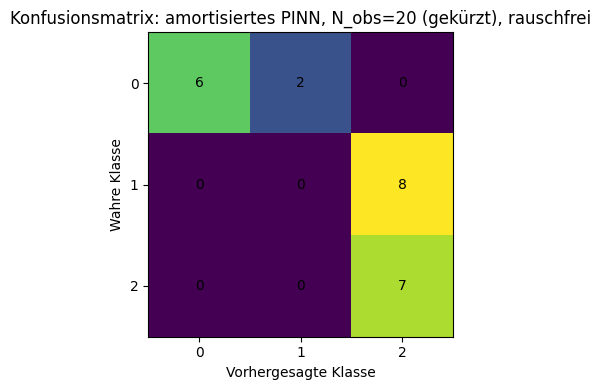

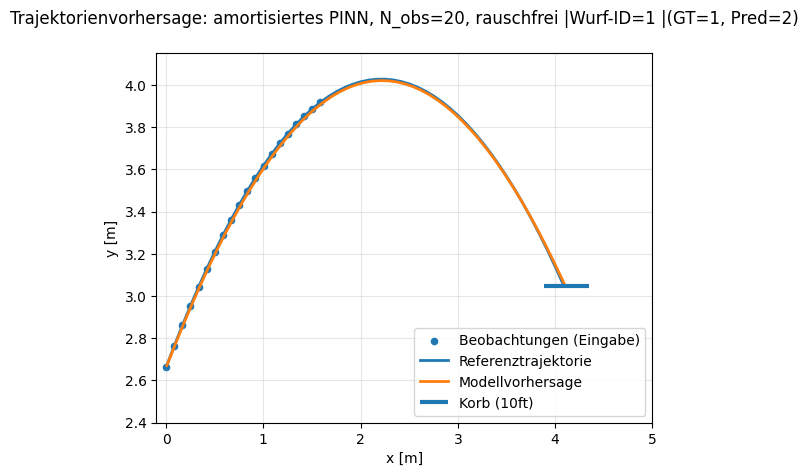

In [16]:
train_ds_clean20 = FreeThrowDataset(df, train_ids, n_obs=20, use_noisy=False)
val_ds_clean20 = FreeThrowDataset(df, val_ids, n_obs=20, use_noisy=False)
test_ds_clean20 = FreeThrowDataset(df, test_ids, n_obs=20, use_noisy=False)

train_loader20 = DataLoader(
    train_ds_clean20, batch_size=64, shuffle=True, collate_fn=collate_fn
)
val_loader20 = DataLoader(
    val_ds_clean20, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader20 = DataLoader(
    test_ds_clean20, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_clean_20 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_20 = train_model(
    model_clean_20,
    train_loader20,
    val_loader20,
    epochs=800,
    lr=2e-3,
    patience=50,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(
    test_loader20,
    model_clean_20,
    titel="Konfusionsmatrix: amortisiertes PINN, N_obs=20 (gekürzt), rauschfrei",
)

demo_reconstruction(
    model_clean_20, test_ds_clean20, n_obs=20, idx=0
)

Epoch    1 | train 358.9395 | val 295.3597 (data 2.0987, phys 272.2201, cls 1.1013)
Epoch   10 | train 56.4187 | val 13.0277 (data 0.1056, phys 12.0414, cls 1.1121)
Epoch   20 | train 3.6518 | val 3.6803 (data 0.1465, phys 2.4084, cls 1.1098)
Epoch   30 | train 1.6598 | val 0.9516 (data 0.0578, phys 0.4594, cls 1.1081)
Epoch   40 | train 1.8093 | val 1.8344 (data 0.0904, phys 0.5450, cls 1.0948)
Epoch   50 | train 1.0829 | val 1.3126 (data 0.0490, phys 0.4675, cls 1.0979)
Epoch   60 | train 0.8625 | val 0.7163 (data 0.0456, phys 0.3599, cls 1.0894)
Epoch   70 | train 0.9606 | val 1.1090 (data 0.0365, phys 0.5605, cls 1.0619)
Epoch   80 | train 0.9866 | val 0.6597 (data 0.0257, phys 0.2298, cls 1.0985)
Epoch   90 | train 0.8902 | val 0.5007 (data 0.0249, phys 0.1875, cls 1.0141)
Epoch  100 | train 0.5279 | val 0.5271 (data 0.0403, phys 0.1196, cls 1.0132)
Epoch  110 | train 2.0684 | val 1.0875 (data 0.0298, phys 0.8123, cls 1.1543)
Epoch  120 | train 0.5179 | val 0.4886 (data 0.0331, ph

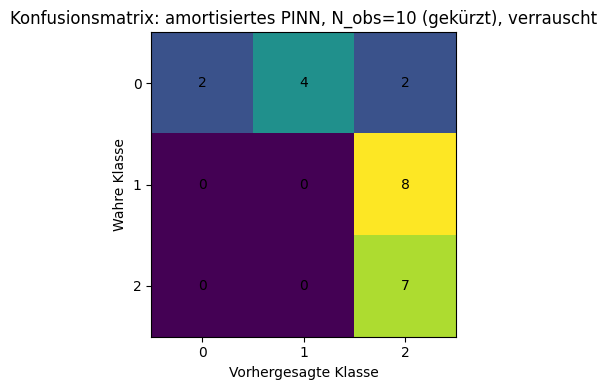

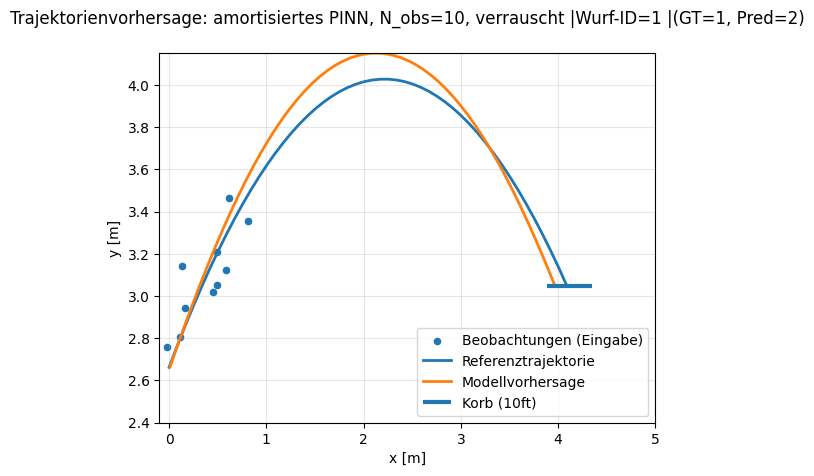

In [17]:
train_ds_noisy = FreeThrowDataset(df, train_ids, n_obs=10, use_noisy=True)
val_ds_noisy = FreeThrowDataset(df, val_ids, n_obs=10, use_noisy=True)
test_ds_noisy = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=True)
test_ds_clean = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=False)

train_loader_noisy = DataLoader(
    train_ds_noisy, batch_size=64, shuffle=True, collate_fn=collate_fn
)
val_loader_noisy = DataLoader(
    val_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)
test_loader_noisy = DataLoader(
    test_ds_noisy, batch_size=64, shuffle=False, collate_fn=collate_fn
)

model_noisy_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_noisy = train_model(
    model_noisy_10,
    train_loader_noisy,
    val_loader_noisy,
    epochs=800,
    lr=2e-3,
    patience=50,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(
    test_loader_noisy,
    model_noisy_10,
    titel="Konfusionsmatrix: amortisiertes PINN, N_obs=10 (gekürzt), verrauscht",
)

demo_reconstruction_noisy_vs_clean(
    model_noisy_10, test_ds_noisy, test_ds_clean, n_obs=10, idx=0
)

Epoch    1 | train 344.7375 | val 270.3904 (data 1.7808, phys 251.4799, cls 1.0991)
Epoch   10 | train 109.6085 | val 217.0101 (data 0.1133, phys 216.2757, cls 1.1162)
Epoch   20 | train 2.4807 | val 2.7860 (data 0.2159, phys 1.5938, cls 1.0975)
Epoch   30 | train 1.9252 | val 1.8456 (data 0.1148, phys 1.2577, cls 1.0963)
Epoch   40 | train 0.9441 | val 0.8612 (data 0.0581, phys 0.4436, cls 1.1062)
Epoch   50 | train 1.1863 | val 0.7463 (data 0.0289, phys 0.4409, cls 1.1032)
Epoch   60 | train 1.2796 | val 1.0270 (data 0.0256, phys 0.6685, cls 1.0996)
Epoch   70 | train 1.0512 | val 0.7240 (data 0.0208, phys 0.5468, cls 1.1021)
Epoch   80 | train 1.0492 | val 1.3079 (data 0.0570, phys 0.8267, cls 1.0937)
Epoch   90 | train 1.1311 | val 1.6020 (data 0.0244, phys 1.2227, cls 1.0566)
Early stopping.
Accuracy: 0.30434782608695654

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00     

c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

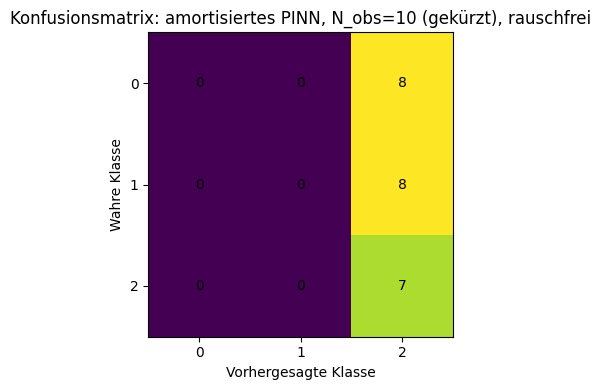

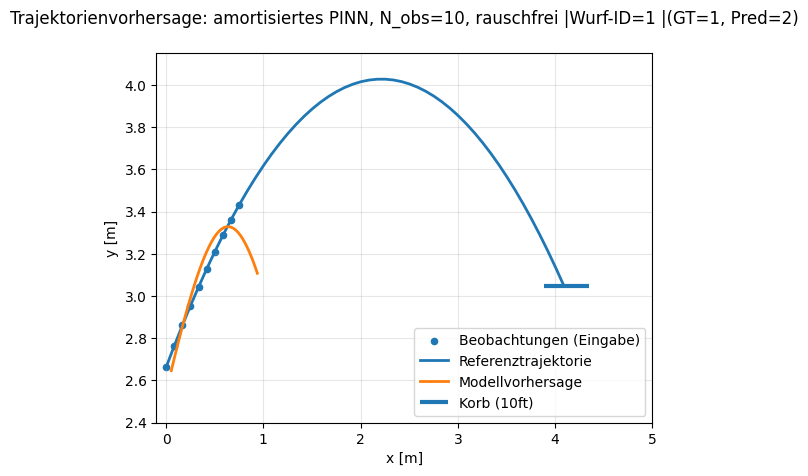

In [18]:
train_ds_clean_10 = FreeThrowDataset(df, train_ids, n_obs=10, use_noisy=False)
val_ds_clean_10 = FreeThrowDataset(df, val_ids, n_obs=10, use_noisy=False)
test_ds_clean_10 = FreeThrowDataset(df, test_ids, n_obs=10, use_noisy=False)

train_loader10 = DataLoader(train_ds_clean_10, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader10 = DataLoader(val_ds_clean_10, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader10 = DataLoader(test_ds_clean_10, batch_size=64, shuffle=False, collate_fn=collate_fn)
model_clean_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

model_clean_10 = AmortizedPINNClassifier(num_classes=int(df["label"].nunique())).to(device)

history_10 = train_model(
    model_clean_10,
    train_loader10,
    val_loader10,
    epochs=800,
    lr=2e-3,
    patience=50,
    n_col=64,
    w_data=5.0,
    w_phys=1.0,
    w_ic=10.0,
    w_cls=0.01,
)

evaluate(
    test_loader10,
    model_clean_10,
    titel="Konfusionsmatrix: amortisiertes PINN, N_obs=10 (gekürzt), rauschfrei",
)

demo_reconstruction(model_clean_10, test_ds_clean_10, n_obs=10, idx=0)